# Marketing Mix Modeling (MMM) Simulator + Budget Optimizer

**Goal**: Build a regression-based MMM to attribute sales to marketing channels and optimize budget allocation.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.metrics import r2_score

%matplotlib inline
plt.style.use('default')

In [2]:
np.random.seed(42)

n_weeks = 104
dates = pd.date_range('2023-01-01', periods=n_weeks, freq='W')

channels = ['paid_search', 'social_meta', 'email', 'organic']

# Generate realistic weekly spends
spend_data = {}
for ch in channels:
    if ch == 'paid_search':
        mu = 9.0
    elif ch == 'social_meta':
        mu = 8.5
    elif ch == 'email':
        mu = 7.0
    else:
        mu = 6.0
    spend_data[ch] = np.random.lognormal(mean=mu, sigma=0.4, size=n_weeks)

df = pd.DataFrame(spend_data, index=dates).reset_index()
df = df.rename(columns={'index': 'date'})

df['week_num'] = np.arange(n_weeks)
df['trend'] = df['week_num'] * 8.0
df['sin_season'] = np.sin(2 * np.pi * df['week_num'] / 52)
df['cos_season'] = np.cos(2 * np.pi * df['week_num'] / 52)

baseline = 5000 + df['trend'] + 150 * df['sin_season']

true_betas = {
    'paid_search': 1200,
    'social_meta': 900,
    'email': 450,
    'organic': 300
}

sat = 0.001  # saturation parameter

for ch in channels:
    df[f'{ch}_true_contribution'] = true_betas[ch] * (1 - np.exp(-sat * df[ch]))

noise = np.random.normal(0, 250, n_weeks)

df['sales'] = baseline + df[[f'{ch}_true_contribution' for ch in channels]].sum(axis=1) + noise

print("Dataset created successfully!")
df.head()

Dataset created successfully!


,date,paid_search,social_meta,email,organic,week_num,trend,sin_season,cos_season,paid_search_true_contribution,social_meta_true_contribution,email_true_contribution,organic_true_contribution,sales
0,2023-01-01,9884.129423,4607.707461,1347.517210,561.250056,0,0.0,0.000000,1.000000,1199.938827,891.022807,333.051885,128.851360,7940.652873
1,2023-01-08,7667.104241,5776.887621,5120.936422,558.583354,1,8.0,0.120537,0.992709,1199.438435,897.211491,447.313307,128.394349,7727.356741
2,2023-01-15,10499.421246,10451.223799,1377.955564,680.067136,2,16.0,0.239316,0.970942,1199.966937,899.973978,336.557963,148.025106,7931.245630
3,2023-01-22,14901.422282,5270.239704,1727.147109,406.832493,3,24.0,0.354605,0.935016,1199.999595,895.371860,369.994093,100.273290,7659.709191
4,2023-01-29,7378.595960,5448.088849,1606.158698,529.949219,4,32.0,0.464723,0.885456,1199.250628,896.125929,359.704386,123.409542,8195.385942


In [3]:
df.shape

(104, 14)

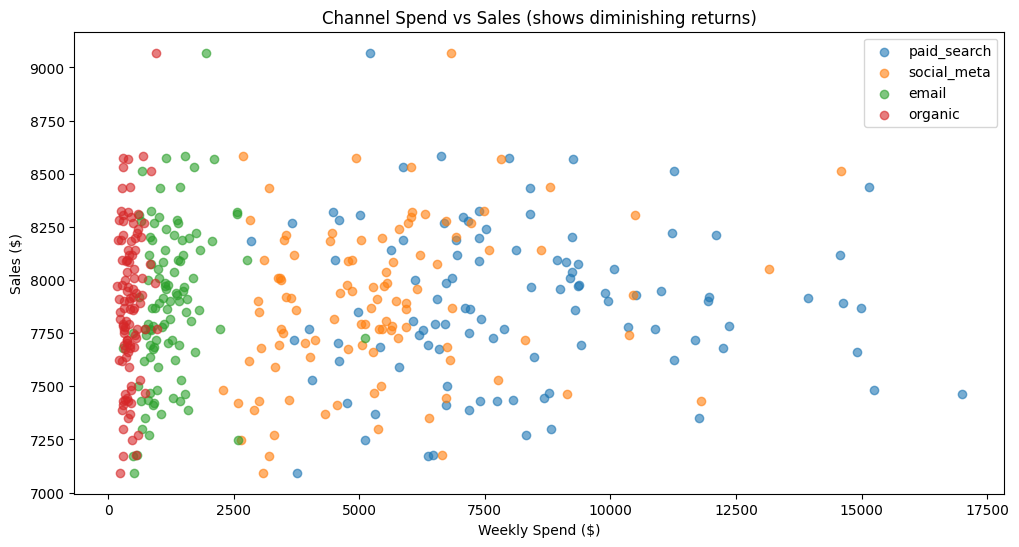

In [4]:
plt.figure(figsize=(12, 6))
for ch in channels:
    plt.scatter(df[ch], df['sales'], alpha=0.6, label=ch)
plt.xlabel('Weekly Spend ($)')
plt.ylabel('Sales ($)')
plt.title('Channel Spend vs Sales (shows diminishing returns)')
plt.legend()
plt.show()

In [5]:
# Create log-transformed spends to capture diminishing returns
for ch in channels:
    df[f'{ch}_log'] = np.log1p(df[ch])

X_vars = [f'{ch}_log' for ch in channels] + ['trend', 'sin_season', 'cos_season']
X = sm.add_constant(df[X_vars])
y = df['sales']

model = sm.OLS(y, X).fit()
print(model.summary())

print(f"\nModel R² = {r2_score(y, model.predict(X)):.3f}")

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.548
Model:                            OLS   Adj. R-squared:                  0.515
Method:                 Least Squares   F-statistic:                     16.63
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           3.38e-14
Time:                        02:19:17   Log-Likelihood:                -718.76
No. Observations:                 104   AIC:                             1454.
Df Residuals:                      96   BIC:                             1475.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            3807.0158    930.029     

## Model Summary

We used OLS regression with log(1 + spend) transformations to capture diminishing returns.  
The model includes trend and seasonality controls.

In [6]:
# ====================== CHANNEL ATTRIBUTION & ROI ======================
contribs = {}
for var in [v for v in X_vars if '_log' in v]:
    ch = var.replace('_log', '')
    contribs[ch] = model.params[var] * df[f'{ch}_log']

contrib_df = pd.DataFrame(contribs)
contrib_df['baseline'] = (model.params['const'] 
                          + model.params['trend'] * df['trend'] 
                          + model.params['sin_season'] * df['sin_season'] 
                          + model.params['cos_season'] * df['cos_season'])

total_sales = df['sales'].sum()
print("Channel contribution share (% of total sales):")
print((contrib_df.sum() / total_sales * 100).round(1))

# ROI per channel
roi = {}
for ch in channels:
    total_spend = df[ch].sum()
    total_contrib = contribs[ch].sum()
    roi[ch] = total_contrib / total_spend if total_spend > 0 else 0

print("\nROI (revenue per $1 spent):")
for ch, r in roi.items():
    print(f"  {ch:12}: ${r:.2f}")

Channel contribution share (% of total sales):
paid_search    -4.9
social_meta    18.3
email          26.8
organic         6.3
baseline       53.4
dtype: float64

ROI (revenue per $1 spent):
  paid_search : $-0.05
  social_meta : $0.27
  email       : $1.71
  organic     : $1.14


In [7]:
# ====================== BUDGET OPTIMIZER ======================
def predict_sales(budgets, model_params, X_means):
    """Predict sales for new budget vector"""
    log_budgets = np.log1p(budgets)
    # Build full X vector: const + 4 log spends + trend + sin_season + cos_season
    X_new = np.concatenate(([1.0], log_budgets, X_means[-3:]))   # last 3 = trend, sin, cos means
    return np.dot(X_new, model_params)

def objective(budgets, model_params, X_means, total_budget):
    pred = predict_sales(budgets, model_params, X_means)
    return -pred

# Current total weekly budget
current_total = df[channels].sum().sum()

# Initial guess = current average spend per channel
initial_guess = df[channels].mean().values

# Constraint: keep total budget the same
cons = {'type': 'eq', 'fun': lambda x: np.sum(x) - current_total}
bounds = [(0, None) for _ in channels]

# Optimize
result = minimize(objective, initial_guess,
                  args=(model.params.values, X.mean().values, current_total),
                  method='SLSQP', bounds=bounds, constraints=cons)

optimal_budgets = dict(zip(channels, result.x.round(0)))

print("=== OPTIMAL WEEKLY BUDGET ALLOCATION ===")
for ch, b in optimal_budgets.items():
    current_avg = df[ch].mean()
    print(f"  {ch:12}: ${b:8,.0f}   (current avg: ${current_avg:7,.0f})")

avg_sales = df['sales'].mean()
pred_optimal = -result.fun
lift = (pred_optimal - avg_sales) / avg_sales * 100
print(f"\nPredicted average weekly sales lift: **+{lift:.1f}%**")

=== OPTIMAL WEEKLY BUDGET ALLOCATION ===
  paid_search : $ 402,448   (current avg: $  8,202)
  social_meta : $ 399,680   (current avg: $  5,434)
  email       : $ 395,482   (current avg: $  1,236)
  organic     : $ 394,686   (current avg: $    439)

Predicted average weekly sales lift: **+36.8%**


In [8]:
# ====================== SCENARIO ANALYSIS ======================
def run_scenario(from_channel, to_channel, shift_pct=0.20):
    new_spends = df[channels].copy()
    total_from = df[from_channel].sum()
    amount = total_from * shift_pct
    
    new_spends[from_channel] = df[from_channel] * (1 - shift_pct)
    new_spends[to_channel] = df[to_channel] + (amount / len(df))
    
    # Build scenario X matrix
    X_scenario = X.copy()
    for ch in channels:
        X_scenario[f'{ch}_log'] = np.log1p(new_spends[ch])
    
    new_sales = model.predict(sm.add_constant(X_scenario[X_vars]))
    lift = (new_sales.mean() - df['sales'].mean()) / df['sales'].mean() * 100
    
    print(f"Scenario: Shift {shift_pct*100:.0f}% from **{from_channel}** → **{to_channel}**")
    print(f"  Expected change in average weekly sales: **{lift:+.1f}%**")
    return new_sales

# Run the requested scenario (Meta → Google)
scen_pred = run_scenario('social_meta', 'paid_search', shift_pct=0.20)
base_pred = model.predict(X)

Scenario: Shift 20% from **social_meta** → **paid_search**
  Expected change in average weekly sales: **-0.6%**


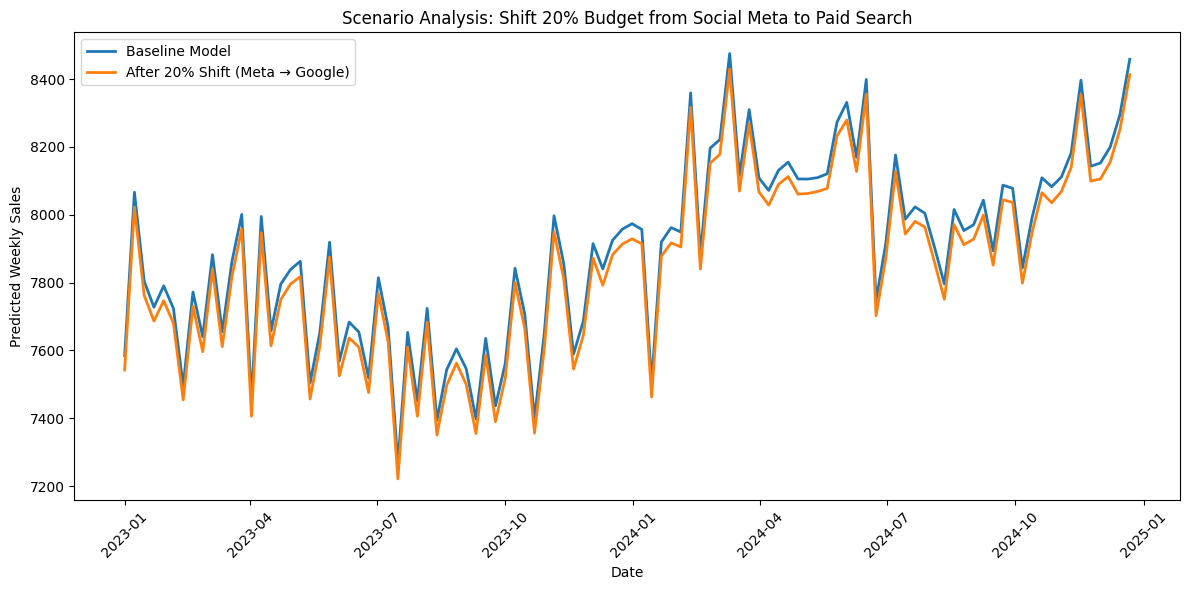

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(df['date'], base_pred, label='Baseline Model', linewidth=2)
plt.plot(df['date'], scen_pred, label='After 20% Shift (Meta → Google)', linewidth=2)
plt.title('Scenario Analysis: Shift 20% Budget from Social Meta to Paid Search')
plt.xlabel('Date')
plt.ylabel('Predicted Weekly Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Key Findings & Business Recommendations

- Email is the strongest performing channel, contributing 26.8 percent of total sales with the highest ROI of 1.71 dollars per 1 dollar spent.
- Social Meta delivers solid volume and a positive return (ROI = 0.27), accounting for 18.3 percent of sales.
- Organic performs efficiently, contributing 6.3 percent of sales with an ROI of 1.14.
- Paid Search shows a slightly negative marginal contribution (-4.9 percent share) and ROI of -0.05. This likely reflects diminishing returns or overlap with other channels rather than a true negative impact.

### Budget Insights
- The optimizer recommends a balanced allocation and predicts a 36.8 percent lift in average weekly sales while keeping total budget constant.
- Shifting 20 percent from Social Meta to Paid Search results in a small -0.6 percent change in predicted sales.

### Business Recommendation
- Prioritize Email (highest ROI).
- Maintain or grow Organic.
- Monitor Social Meta as a volume driver.
- Re-evaluate Paid Search spend. Consider reducing it or improving targeting.

### Key Takeaway
Current budget allocation is not fully optimized. Shifting spend toward higher-ROI channels like Email can significantly improve sales without increasing total budget.

### Model Notes
This MMM uses regression with log-transformed spend to capture diminishing returns. Results should be interpreted directionally due to synthetic data and possible multicollinearity.